In [1]:
# Runtime evidence: this cell checks the environment actually used by the kernel.
import sys as _shape_sys, json as _shape_json, importlib.util as _shape_util
print("SHAPE_RUNTIME_PROVENANCE=" + _shape_json.dumps({
    "python_executable": _shape_sys.executable,
    "python_version": _shape_sys.version.split()[0],
    "shape_lab_origin": _shape_util.find_spec("shape_lab").origin
}))
del _shape_sys, _shape_json, _shape_util


SHAPE_RUNTIME_PROVENANCE={"python_executable": "/opt/pyvenv/bin/python", "python_version": "3.13.5", "shape_lab_origin": "/tmp/shape-course-q90rdcpz/course/src/shape_lab/__init__.py"}


# Business panels: availability time is part of the feature

**Beginner route:** read the [case lesson](../lessons/grunfeld.md) and [dataset card](../cards/grunfeld.md). Predict each result before executing.

Source: [Grunfeld; 11-firm reconstruction documented by Kleiber and Zeileis (2008); statsmodels distribution.](https://www.statsmodels.org/stable/datasets/generated/grunfeld.html). Snapshot obtained by offline export from statsmodels 0.14.6. Numerical results below are our computations, not source claims.

This fixed test partition is a teaching demonstration, not an untouched future benchmark.

In [2]:
from IPython import get_ipython
if get_ipython() is not None:
    get_ipython().run_line_magic('matplotlib','inline')
from pathlib import Path
import sys, json, hashlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression, Ridge, LinearRegression
from sklearn.metrics import accuracy_score, balanced_accuracy_score, log_loss, mean_absolute_error, mean_squared_error, roc_auc_score, confusion_matrix
ROOT = next(p for p in (Path.cwd(), *Path.cwd().parents) if (p / "src/shape_lab").is_dir())
sys.path.insert(0, str(ROOT / "src"))
from shape_lab.industries import *
from shape_lab.persistence import rips_filtration, persistent_homology, diagram
CASE = "grunfeld"
OUT = ROOT / "reports/v6/industries" / CASE
OUT.mkdir(parents=True, exist_ok=True)
SEED = 20260920

def write_json(name, value):
    def convert(x):
        if isinstance(x, np.ndarray): return x.tolist()
        if isinstance(x, np.generic): return x.item()
        raise TypeError(type(x).__name__)
    (OUT / name).write_text(json.dumps(value, indent=2, default=convert, allow_nan=False))

def plot_done(name):
    plt.tight_layout()
    plt.savefig(OUT / (name + ".png"), dpi=125)
    plt.show()

def regression_metrics(y, pred):
    return {"mae":float(mean_absolute_error(y,pred)),"rmse":float(mean_squared_error(y,pred)**.5)}

def class_metrics(y, pred):
    return {"accuracy":float(accuracy_score(y,pred)),"balanced_accuracy":float(balanced_accuracy_score(y,pred))}

def stratified_split(y):
    index=np.arange(len(y))
    train, other=train_test_split(index,test_size=.4,random_state=SEED,stratify=y)
    val,test=train_test_split(other,test_size=.5,random_state=SEED,stratify=y[other])
    return {"train":np.sort(train),"validation":np.sort(val),"test":np.sort(test)}

def save_split(split, ids):
    frames=[pd.DataFrame({"example_index":v,"source_id":np.asarray(ids)[v],"partition":k}) for k,v in split.items()]
    pd.concat(frames,ignore_index=True).to_csv(OUT / "split.csv",index=False)

def topology_report(points, name):
    bars=persistent_homology(rips_filtration(points,max_homology=1),max_dim=1)
    finite=[{"dimension":b.dim,"birth":b.birth,"death":b.death} for b in bars if np.isfinite(b.death)]
    write_json(name+".json",{"points":len(points),"coefficient_field":2,"edge_convention":"distance <= epsilon","finite_bars":finite,"essential_h0":1,"role":"exploratory descriptor, not significance"})
    plt.figure(figsize=(7,4))
    for dim in (0,1):
        a=diagram(bars,dim,finite_only=True)
        if len(a): plt.scatter(a[:,0],a[:,1],label="H"+str(dim),s=22)
    plt.xlabel("Birth (declared metric units)");plt.ylabel("Death (same units)");plt.title(name.replace('_',' '));plt.legend()
    plot_done(name)
    return finite

df, meta = load_dataset(CASE)
print(meta["title"])
print("Shape:",df.shape,"; snapshot SHA-256:",meta["data_sha256"])
print("Observation unit:",meta["observation_unit"])
display(df.head())
write_json("protocol.json",{"dataset":CASE,"seed":SEED,"data_sha256":meta["data_sha256"],"code_sha256":hashlib.sha256((ROOT/"src/shape_lab/industries.py").read_bytes()).hexdigest(),"data_kind":"observed","evaluation":"fixed teaching experiment; displayed test outcomes are now exposed","external_validation":False})


Firm panels, timestamps and prediction availability
Shape: (220, 6) ; snapshot SHA-256: 69c2ae99098dbc3735e5a10d1855341ea3db6160b1c9890cc33236dca9914df6
Observation unit: One firm-year record. A repeated firm is not a new independent company.


,row_id,invest,value,capital,firm,year
0,0,317.6,3078.5,2.8,General Motors,1935
1,1,391.8,4661.7,52.6,General Motors,1936
2,2,410.6,5387.1,156.9,General Motors,1937
3,3,257.7,2792.2,209.2,General Motors,1938
4,4,330.8,4313.2,203.4,General Motors,1939


## 1. Respect the panel structure

A panel repeatedly observes the same entity. This table contains eleven firms, with annual records over twenty years. We create prior-year predictors within each firm. In particular, same-year year-end market value is not available at the beginning of that year.

This is an explicitly simplified availability assumption: the notebook does not contain publication-time or revision-vintage data.

In [3]:
panel=df.sort_values(["firm","year"]).copy()
for c in ("invest","value","capital"):
    panel["lag_"+c]=panel.groupby("firm")[c].shift(1)
panel=panel.dropna().reset_index(drop=True)
features=["lag_invest","lag_value","lag_capital"]
x=panel[features].to_numpy(float);y=panel.invest.to_numpy(float)
split={"train":np.flatnonzero(panel.year.to_numpy()<=1947),"validation":np.flatnonzero(panel.year.between(1948,1950)),"test":np.flatnonzero(panel.year>=1951)}
save_split(split,panel.row_id)
assert panel.iloc[split["train"]].year.max()<panel.iloc[split["test"]].year.min()
print(panel.groupby("year").size().head());print({k:len(v) for k,v in split.items()})

year
1936    11
1937    11
1938    11
1939    11
1940    11
dtype: int64
{'train': 132, 'validation': 33, 'test': 44}


## 2. Compare with doing almost nothing

The last observed investment value is a serious baseline. A pooled ridge model shares one relationship across firms; it does not imply that all firms have the same structural mechanism. Both MAE and RMSE retain the source monetary scale. We do not invent a million-dollar multiplier.

In [4]:
scale=TrainScaler.fit(x[split["train"]]);z=scale.transform(x)
model=Ridge(alpha=1).fit(z[split["train"]],y[split["train"]]);results={}
for key in ("validation","test"):
    ix=split[key];pred=model.predict(z[ix]);last=x[ix,0]
    results[key]={"ridge":regression_metrics(y[ix],pred),"last_investment":regression_metrics(y[ix],last),"n":len(ix)}
    out=panel.iloc[ix][["row_id","firm","year"]].copy();out["observed"]=y[ix];out["ridge"]=pred;out["last_investment"]=last;out.to_csv(OUT/(key+"_predictions.csv"),index=False)
write_json("results.json",results);display(pd.DataFrame({k:v["ridge"] for k,v in results.items()}))
write_json("preprocessing.json",{"features":features,"mean":scale.mean,"scale":scale.scale,"predictor_availability":"previous annual record assumed available; publication timestamps absent"})

,validation,test
mae,19.523125,41.201072
rmse,30.511803,90.192043


## 3. Look at errors by firm instead of hiding them in an average

A low pooled error can hide a poorly modeled firm. The following view is a descriptive breakdown of this exposed test set, not a basis for tuning firm-specific models against it. A new-firm claim would require a different, entity-disjoint evaluation.

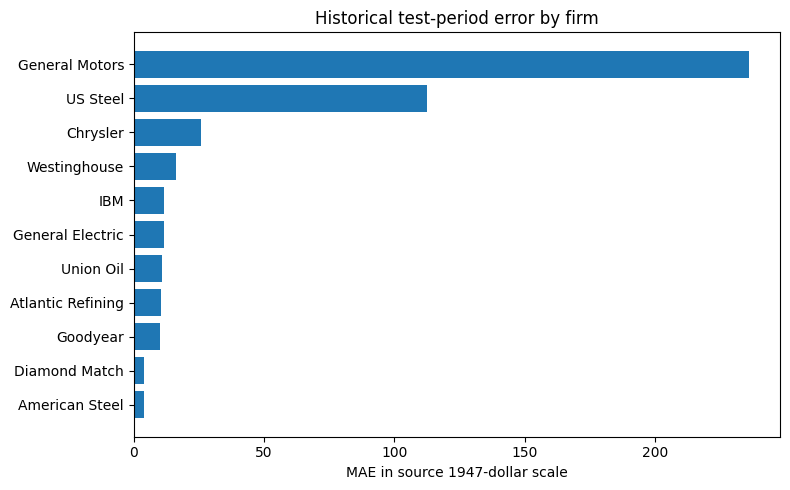

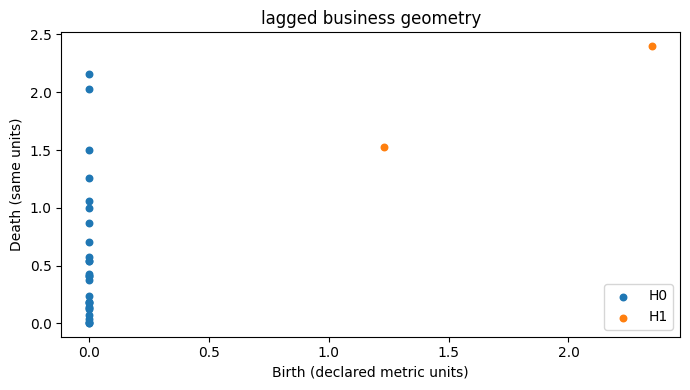

In [5]:
out=pd.read_csv(OUT/"test_predictions.csv");out["absolute_error"]=abs(out.observed-out.ridge)
by=out.groupby("firm").absolute_error.mean().sort_values();by.to_csv(OUT/"test_error_by_firm.csv")
plt.figure(figsize=(8,5));plt.barh(by.index,by.values);plt.xlabel("MAE in source 1947-dollar scale");plt.title("Historical test-period error by firm");plot_done("firm_errors")
refs=np.random.default_rng(SEED).choice(split["train"],size=28,replace=False)
_ = topology_report(z[refs],"lagged_business_geometry")

## 4. Separate prediction from intervention

No fitted coefficient here is a causal effect of increasing a firm's equipment. The data contain selection, omitted variables, repeated firms, and historical accounting conventions.

Exercise: design two different tests—future years of known firms and years from previously unseen firms. Explain why these answer different questions, and why revised financial data complicate a genuine real-time historical simulation.

## Save your evidence

Create `my_work/industries/grunfeld.md` with your prediction, actual result, explanation, one failed assumption and one claim the evidence does not justify. Use the separate learner notebook only after you understand the worked code. No notebook execution automatically marks your learning complete.